# Benchmark Baseline: Caratterizzazione del Disturbo Prandiale non Annunciato
Questo notebook analizza la risposta di un controllore PID convenzionale su paziente virtuale `adult#001` (piattaforma *simglucose*).
Vengono esplorate:
1. Condizioni nominali stazionarie a digiuno.
2. Sensibilità al carico prandiale non annunciato (30g, 60g, 90g CHO).
3. Sensibilità alla cinetica di assorbimento (pasto rapido vs pasto prolungato 60g CHO).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from simglucose.simulation.env import T1DSimEnv
from simglucose.actuator.pump import InsulinPump
from simglucose.sensor.cgm import CGMSensor
from simglucose.patient.t1dpatient import T1DPatient
from simglucose.simulation.scenario import CustomScenario
from simglucose.controller.base import Controller, Action

class BaselinePIDController(Controller):
    def __init__(self, target=115.0, kp=0.0006, ki=0.00001, kd=0.004, basal_rate=0.0248):
        self.target = target
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.basal_rate = basal_rate
        self.integral_error = 0.0
        self.prev_cgm = None
        # Parametri osservatore IOB a due compartimenti (Hovorka)
        self.tau_s = 50.0
        self.s1 = 0.0
        self.s2 = 0.0

    def policy(self, observation, reward, done, **info):
        cgm = observation.CGM
        error = cgm - self.target
        d_error = 0.0 if self.prev_cgm is None else (self.prev_cgm - cgm)
        self.prev_cgm = cgm

        # Anti-windup statico standard
        self.integral_error = np.clip(self.integral_error + error, -5000.0, 15000.0)
        correction = (self.kp * error) + (self.ki * self.integral_error) + (self.kd * d_error)
        u = max(0.0, self.basal_rate + correction)

        # Aggiornamento stima IOB per monitoraggio
        u_act = max(0.0, u - self.basal_rate)
        self.s1 += (u_act - self.s1 / self.tau_s)
        self.s2 += (self.s1 / self.tau_s - self.s2 / self.tau_s)
        iob_est = self.s1 + self.s2

        return Action(basal=u, bolus=0.0), iob_est

    def reset(self):
        self.integral_error = 0.0
        self.prev_cgm = None
        self.s1 = 0.0
        self.s2 = 0.0


In [6]:
def run_sim(scenario_list, sim_hours=16):
    start = datetime(2026, 10, 6, 8, 0, 0)
    scen = CustomScenario(start_time=start, scenario=scenario_list)
    patient = T1DPatient.withName("adult#001")
    sensor = CGMSensor.withName("Dexcom", seed=10)
    pump = InsulinPump.withName("Insulet")
    env = T1DSimEnv(patient, sensor, pump, scen)
    ctrl = BaselinePIDController(target=115.0)

    obs, reward, done, info = env.reset()
    ctrl.reset()
    res = {'time': [], 'BG': [], 'CGM': [], 'insulin': [], 'IOB': []}

    for step in range(sim_hours * 60):
        t = start + timedelta(minutes=step)
        action, iob = ctrl.policy(obs, reward, done, **info)
        obs, reward, done, info = env.step(action)
        res['time'].append(t)
        res['BG'].append(env.patient.observation.Gsub)
        res['CGM'].append(obs.CGM)
        res['insulin'].append(action.basal)
        res['IOB'].append(iob)

    df = pd.DataFrame(res)
    bg = df['BG']
    metrics = {
        'TIR [%]': (np.sum((bg >= 70) & (bg <= 180)) / len(bg)) * 100.0,
        'TAR [%]': (np.sum(bg > 180) / len(bg)) * 100.0,
        'TBR [%]': (np.sum(bg < 70) / len(bg)) * 100.0,
        'Picco [mg/dL]': bg.max(),
        'Nadir [mg/dL]': bg.min()
    }
    return df, metrics


In [7]:
# Esecuzione scenari
scenarios = {
    'Digiuno': [],
    '30g Rapido': [(timedelta(hours=4), 30)],
    '60g Rapido': [(timedelta(hours=4), 60)],
    '90g Rapido': [(timedelta(hours=4), 90)],
    '60g Lento': [(timedelta(hours=4), 20), (timedelta(hours=4, minutes=30), 20), (timedelta(hours=5), 20)]
}

dfs, summary = {}, []
for name, scen in scenarios.items():
    d, m = run_sim(scen)
    dfs[name] = d
    m['Scenario'] = name
    summary.append(m)

pd.DataFrame(summary)[['Scenario', 'TIR [%]', 'TAR [%]', 'TBR [%]', 'Picco [mg/dL]', 'Nadir [mg/dL]']].round(2)


,Scenario,TIR [%],TAR [%],TBR [%],Picco [mg/dL],Nadir [mg/dL]
0,Digiuno,71.98,6.46,21.56,195.37,42.57
1,30g Rapido,59.06,15.94,25.00,211.03,44.34
2,60g Rapido,49.69,12.29,38.02,210.70,27.06
3,90g Rapido,42.29,11.56,46.15,217.24,3.54
4,60g Lento,50.10,12.29,37.60,210.57,28.20


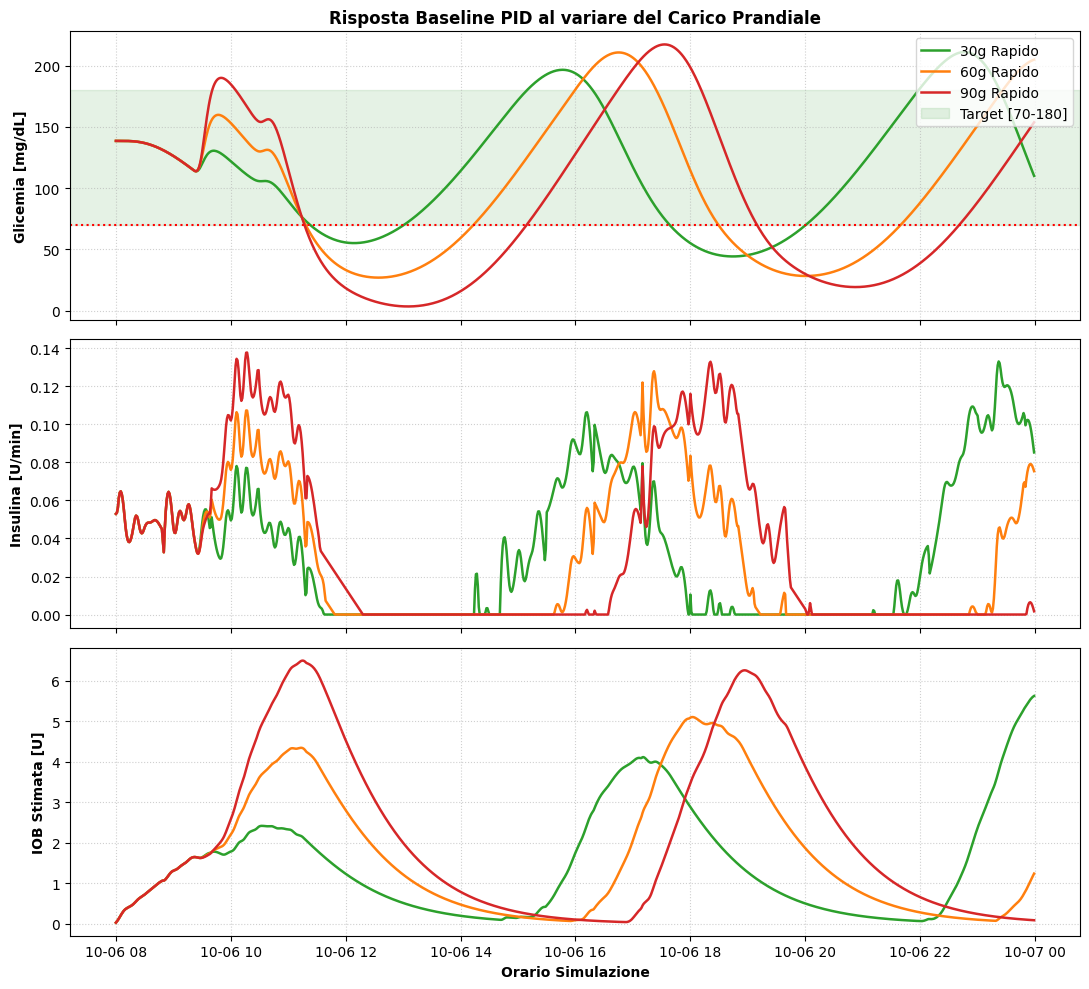

In [8]:
# Grafico a 3 pannelli (Glicemia, Insulina, IOB) come richiesto da Giada
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

colors = {'30g Rapido': '#2ca02c', '60g Rapido': '#ff7f0e', '90g Rapido': '#d62728'}
for name in ['30g Rapido', '60g Rapido', '90g Rapido']:
    ax1.plot(dfs[name]['time'], dfs[name]['BG'], label=name, color=colors[name], lw=1.8)
    ax2.plot(dfs[name]['time'], dfs[name]['insulin'], label=name, color=colors[name], lw=1.8)
    ax3.plot(dfs[name]['time'], dfs[name]['IOB'], label=name, color=colors[name], lw=1.8)

ax1.axhspan(70, 180, color='green', alpha=0.1, label='Target [70-180]')
ax1.axhline(70, color='red', ls=':')
ax1.set_ylabel('Glicemia [mg/dL]', fontweight='bold')
ax1.set_title('Risposta Baseline PID al variare del Carico Prandiale', fontweight='bold')
ax1.grid(True, ls=':', alpha=0.6); ax1.legend(loc='upper right')

ax2.set_ylabel('Insulina [U/min]', fontweight='bold')
ax2.grid(True, ls=':', alpha=0.6)

ax3.set_ylabel('IOB Stimata [U]', fontweight='bold')
ax3.set_xlabel('Orario Simulazione', fontweight='bold')
ax3.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()
